## Task 8 : PHÁT HIỆN OUTLIERS VÀ CHUẨN HÓA DỮ LIỆU RFM

### 1. Đọc dữ liệu rfm

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
rfm = pd.read_csv("../data/processed/rfm_table.csv")

### 2. Kiểm tra thông tin dữ liệu

In [3]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4324 non-null   float64
 1   Recency     4324 non-null   int64  
 2   Frequency   4324 non-null   int64  
 3   Monetary    4324 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.3 KB


### 3. Thống kê mô tả

In [4]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4324.000000,4324.000000,4324.000000,4324.000000
mean,15301.250925,92.350833,4.226873,1922.633602
std,1720.313978,100.258736,7.567515,8314.161895
min,12347.000000,0.000000,1.000000,2.900000
25%,13815.750000,17.000000,1.000000,301.225000
50%,15299.500000,50.000000,2.000000,656.430000
75%,16778.250000,143.000000,5.000000,1615.045000
max,18287.000000,373.000000,203.000000,278742.020000


### 4. Tính độ lệch

In [5]:
rfm[["Recency","Frequency","Monetary"]].skew()

Recency       1.240940
Frequency    11.843607
Monetary     21.487953
dtype: float64

### 5. Vẽ histogram phân phối R, F, M

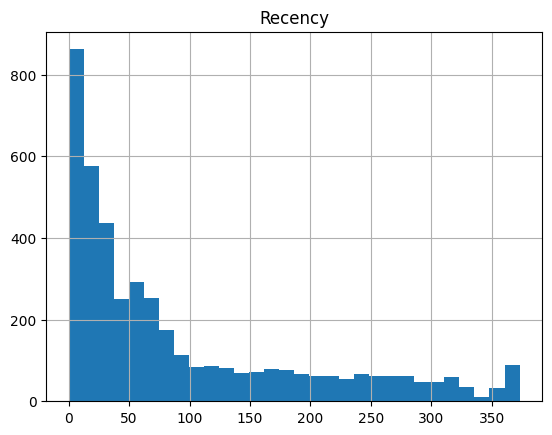

In [6]:
import matplotlib.pyplot as plt

rfm["Recency"].hist(bins=30)

plt.title("Recency")
plt.show()

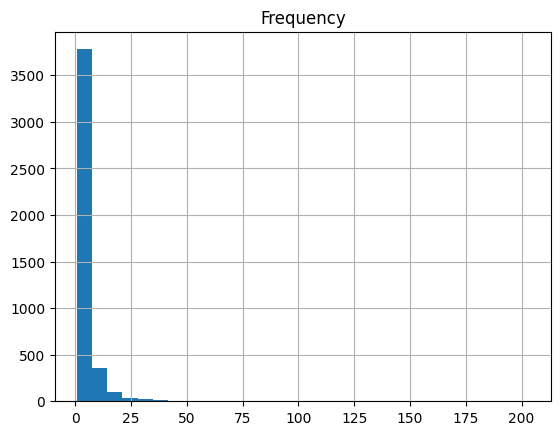

In [7]:
rfm["Frequency"].hist(bins=30)

plt.title("Frequency")
plt.show()

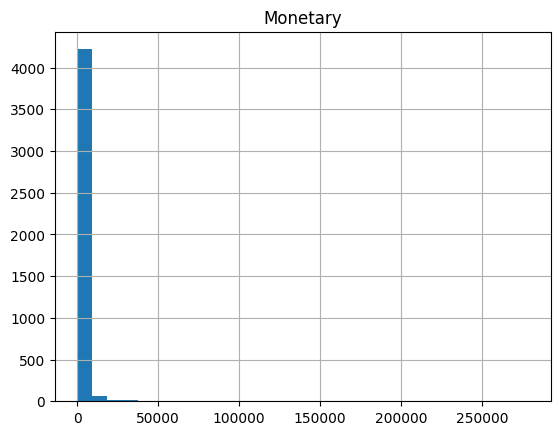

In [8]:
rfm["Monetary"].hist(bins=30)

plt.title("Monetary")
plt.show()

**Nhận xét:** Phân phối dữ liệu của các thuộc tính Frequency, Monetary bị lệch phải mạnh, chứng tỏ tồn tại các giá trị outliers rất lớn --> Quyết định áp dụng phép biến đổi logarithm transfrom để giảm độ lệch của phân phối, đưa phân phối dữ liệu về scale dễ quan sát hơn

### 6. Áp dụng phép biến đổi Logarithm cho các thuộc tính R, F, M

In [9]:
## Áp dụng Log Transformation để giảm độ lệch của các biến Frequency và Monetary
rfm["Frequency_log"] = np.log1p(
    rfm["Frequency"]
)

rfm["Monetary_log"] = np.log1p(
    rfm["Monetary"]
)

## Kiểm tra độ lệch sau khi áp dụng Log Transformation
rfm[
    [
        "Frequency_log",
        "Monetary_log"
    ]
].skew()

Frequency_log    1.216910
Monetary_log     0.352663
dtype: float64

### 7. Vẽ biểu đồ phân phối của F, M sau khi biến đổi Log

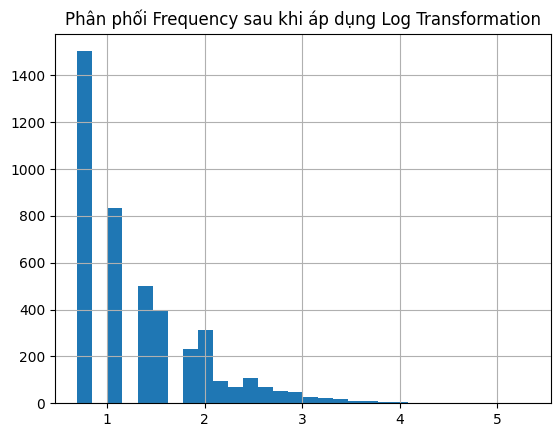

In [10]:
rfm["Frequency_log"].hist(bins=30)

plt.title("Phân phối Frequency sau khi áp dụng Log Transformation")
plt.show()

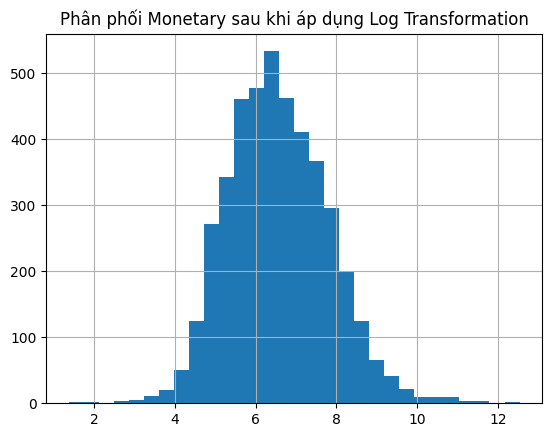

In [11]:
rfm["Monetary_log"].hist(bins=30)

plt.title("Phân phối Monetary sau khi áp dụng Log Transformation")
plt.show()

**Nhận xét:** Độ lệch đã giảm đáng kể sang khi áp dụng log transformation, phân phối Frequecy vẫn còn lệch phải, trong khi đó phân phối Monetary lại xấp xỉ phân phối chuẩn --> Sẵn sàng chuẩn hóa dữ liệu bằng kỹ thuật Standardization

### 8. Chuẩn hóa R, F, M bằng StandardScaler

In [12]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[
        [
            "Recency",
            "Frequency_log",
            "Monetary_log"
        ]
    ]
)

### 9. Chuyển kết quả sau khi chuẩn hóa thành DataFrame

In [13]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ]
)

rfm_scaled.insert(
    0,
    "CustomerID",
    rfm["CustomerID"]
)

rfm_scaled.describe()

,CustomerID,Recency,Frequency,Monetary
count,4324.000000,4.324000e+03,4.324000e+03,4.324000e+03
mean,15301.250925,4.436784e-17,1.552874e-16,-9.859520e-17
std,1720.313978,1.000116e+00,1.000116e+00,1.000116e+00
min,12347.000000,-9.212316e-01,-9.509185e-01,-4.157915e+00
25%,13815.750000,-7.516507e-01,-9.509185e-01,-6.797203e-01
50%,15299.500000,-4.224642e-01,-3.545631e-01,-5.833738e-02
75%,16778.250000,5.052430e-01,6.649133e-01,6.607762e-01
max,18287.000000,2.799573e+00,5.851461e+00,4.778701e+00


### 10. Lưu dữ liệu

In [ ]:
rfm_scaled.to_csv(
    "../data/processed/rfm_scaled.csv",
    index=False
)